# Modelling data - Version 5

This version includes all variables in the dataset **except for fuel consumption and cost variables**: FUEL_CONS_ACPM, FUEL_CONS_CARBON, FUEL_CONS_COMBUSTOLEO, FUEL_CONS_CRUDO, FUEL_CONS_GAS, FUEL_CONS_GAS_NI, FUEL_CONS_GLP, FUEL_COST_CARBON, FUEL_COST_GAS, FUEL_COST_GAS_NI, FUEL_COST_COMBUSTOLEO.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
# Dropping column "SOLAR"

df = df.drop(columns=["FUEL_CONS_ACPM", "FUEL_CONS_CARBON", "FUEL_CONS_COMBUSTOLEO", 
                      "FUEL_CONS_CRUDO", "FUEL_CONS_GAS", "FUEL_CONS_GAS_NI", "FUEL_CONS_GLP",
                      "FUEL_COST_CARBON", "FUEL_COST_GAS", "FUEL_COST_GAS_NI", "FUEL_COST_COMBUSTOLEO"])
df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0,0.42,-0.73,-0.02


In [4]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FECHA_HORA          48192 non-null  object 
 1   YEAR                48192 non-null  int64  
 2   MONTH               48192 non-null  int64  
 3   DAY                 48192 non-null  int64  
 4   HORA                48192 non-null  int64  
 5   PRECIO              48192 non-null  float64
 6   TERMICA             48192 non-null  float64
 7   HIDRAULICA          48192 non-null  float64
 8   SOLAR               48192 non-null  float64
 9   COGENERADOR         48192 non-null  float64
 10  EOLICA              48192 non-null  float64
 11  NIVEL_ENSO          48192 non-null  float64
 12  IPC_VAR_MOM_PCT     48192 non-null  float64
 13  IPP_VAR_PN_MOM_PCT  48192 non-null  float64
 14  IPP_VAR_OI_MOM_PCT  48192 non-null  float64
dtypes: float64(10), int64(4), object(1)
me

In [5]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA            0
YEAR                  0
MONTH                 0
DAY                   0
HORA                  0
PRECIO                0
TERMICA               0
HIDRAULICA            0
SOLAR                 0
COGENERADOR           0
EOLICA                0
NIVEL_ENSO            0
IPC_VAR_MOM_PCT       0
IPP_VAR_PN_MOM_PCT    0
IPP_VAR_OI_MOM_PCT    0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [5]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [7]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 13)
Test set size: (9639, 13)


## Baseline Models

In [8]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [9]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression  0.014479  151.509369   57321.417329  215.521075
Ridge              0.014633  151.503029   57318.891777  215.512422
Lasso              0.078903  148.104458   55820.931604  211.165842
ElasticNet         0.228553  145.052444   54920.053344  200.329943
Decision Tree     -2.065781  200.725548  123166.196828  324.972020
Random Forest     -1.088502  171.349115   96596.600813  270.396442
Gradient Boosting -0.446248  136.583280   53724.656460  208.388190
SVR               -0.671301  232.628079  131134.204722  304.217116
KNN               -0.203772  161.288425   67124.308622  231.029533


In [10]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [11]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [12]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: 0.24514973691010228
Best params: {'model__alpha': 1, 'model__l1_ratio': 0.7}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -1.0781652883013348
Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.17002729581265968
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}


{'ElasticNet': {'best_score': 0.24514973691010228,
  'best_params': {'model__alpha': 1, 'model__l1_ratio': 0.7}},
 'RandomForest': {'best_score': -1.0781652883013348,
  'best_params': {'model__max_depth': 10,
   'model__min_samples_split': 10,
   'model__n_estimators': 100}},
 'GradientBoosting': {'best_score': -0.17002729581265968,
  'best_params': {'model__learning_rate': 0.1,
   'model__max_depth': 3,
   'model__n_estimators': 500}}}

In [13]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [14]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [15]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-0.676849,151.506170,72212.572573,236.741602
LightGBM,-0.387727,142.168518,64337.409502,222.013016
CatBoost,-0.091041,144.071352,59825.286846,215.377923


## Time Series Forecasting

### Splits the training and test sets as a time series

In [16]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 13)
Test set size: (9639, 13)


In [17]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -0.056147  166.380457   68394.815589  231.660105
Ridge             -0.055206  166.362477   68390.590657  231.631914
Lasso              0.073871  163.045732   67384.646164  226.470940
ElasticNet        -0.230723  177.984481   77971.238855  244.410101
Decision Tree     -0.269209  180.797934   93778.725805  254.772988
Random Forest     -0.072029  172.870142   90248.455369  245.877779
Gradient Boosting -0.009882  147.182803   59374.619002  214.280520
SVR               -1.181718  252.507591  155976.299925  338.529100
KNN               -0.485882  182.710133   78975.446887  251.178978


### Prophet

In [18]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0,0.42,-0.73,-0.02


11:18:29 - cmdstanpy - INFO - Chain [1] start processing
11:20:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


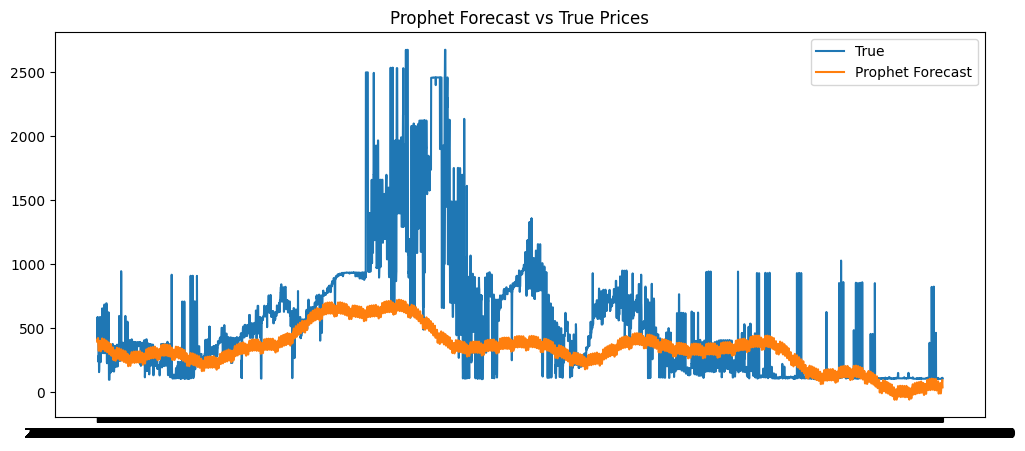

In [19]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 227.04, RMSE: 419.69, R2: 0.30


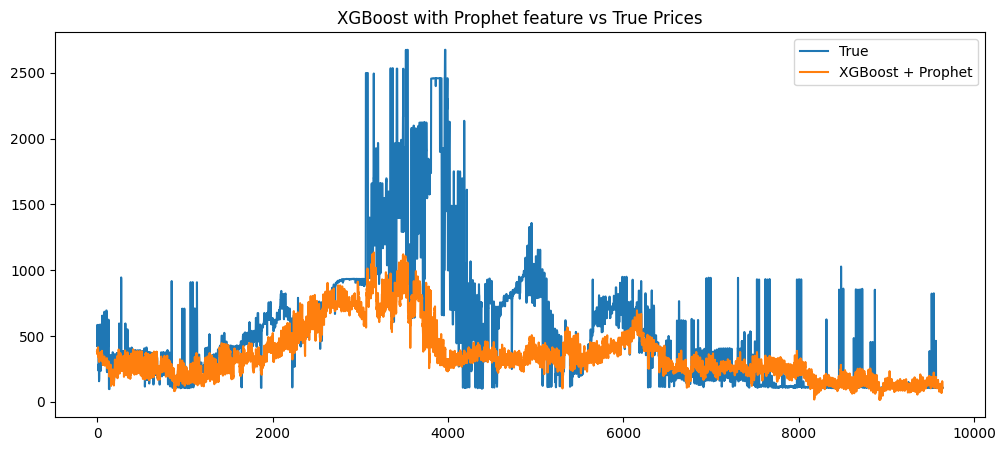

In [20]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [6]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [7]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,2020,1,2,0,1608662.67,4585681.98,0.0,19184.34,4908.48,1.0,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,2020,1,2,1,1508655.14,4466153.60,0.0,19342.06,3836.61,1.0,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,2020,1,2,2,1413968.65,4520386.10,0.0,20345.52,5343.35,1.0,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,2020,1,2,3,1369278.08,4470436.67,0.0,21123.41,3942.81,1.0,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,2020,1,2,4,1353049.36,4558570.93,0.0,25773.80,2363.15,1.0,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 88.12, RMSE: 250.07, R2: 0.75


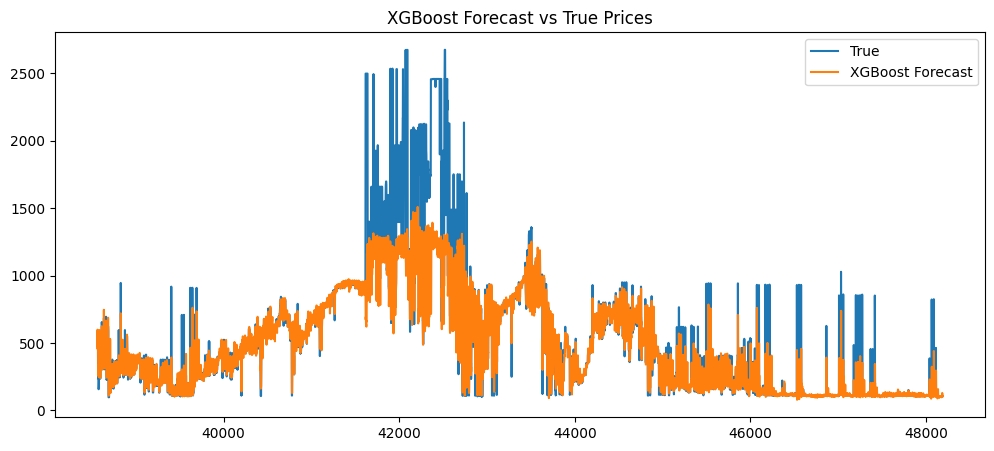

In [23]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [8]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7624
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 37
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   88.147106  250.022854  0.751364
LightGBM  80.085662  223.776580  0.800825
CatBoost  81.032254  222.719714  0.802702


### Boosting with lags (tunning)

In [9]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [10]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-29 09:55:57,574] A new study created in memory with name: no-name-426a06f1-6aa1-4588-9f03-8b2d0aadbcae


Running Optuna for XGBoost...


[I 2025-08-29 09:56:16,974] Trial 0 finished with value: 244.87125741939204 and parameters: {'n_estimators': 911, 'learning_rate': 0.0262272403381152, 'max_depth': 9, 'subsample': 0.8150501207380416, 'colsample_bytree': 0.8389493214194055, 'gamma': 3.8860951580630982, 'reg_alpha': 1.7991570662257668, 'reg_lambda': 0.4527662082885964}. Best is trial 0 with value: 244.87125741939204.
[I 2025-08-29 09:56:31,166] Trial 1 finished with value: 250.2138961974007 and parameters: {'n_estimators': 358, 'learning_rate': 0.04691248480050102, 'max_depth': 11, 'subsample': 0.8160866634739455, 'colsample_bytree': 0.7188719554650874, 'gamma': 1.8047974304673453, 'reg_alpha': 2.212522112330213, 'reg_lambda': 3.1445700095884312}. Best is trial 0 with value: 244.87125741939204.
[I 2025-08-29 09:56:43,775] Trial 2 finished with value: 239.93993333101454 and parameters: {'n_estimators': 1483, 'learning_rate': 0.03250580600165097, 'max_depth': 5, 'subsample': 0.6433929362184323, 'colsample_bytree': 0.907888

Best params for XGBoost: {'n_estimators': 543, 'learning_rate': 0.014882123328124405, 'max_depth': 3, 'subsample': 0.8700778672617162, 'colsample_bytree': 0.859952943717363, 'gamma': 3.07985305833219, 'reg_alpha': 2.054196152777388, 'reg_lambda': 3.285158896921202}
Best RMSE: 214.6923

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7624
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 37
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

[I 2025-08-29 10:08:12,340] Trial 0 finished with value: 224.77752083689427 and parameters: {'n_estimators': 933, 'learning_rate': 0.036044888113738516, 'num_leaves': 112, 'max_depth': 8, 'min_child_samples': 32, 'subsample': 0.7625124410343012, 'colsample_bytree': 0.9613532107137818}. Best is trial 0 with value: 224.77752083689427.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7624
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 37
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-08-29 10:18:43,558] Trial 93 finished with value: 210.07152671290493 and parameters: {'n_estimators': 1079, 'learning_rate': 0.011682770461000126, 'num_leaves': 71, 'max_depth': 3, 'min_child_samples': 98, 'subsample': 0.7378795920635126, 'colsample_bytree': 0.8213806953794723}. Best is trial 92 with value: 209.8866776032364.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7624
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 37
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-08-29 11:18:02,062] Trial 0 finished with value: 258.15433627358254 and parameters: {'iterations': 390, 'learning_rate': 0.07375005825876209, 'depth': 12, 'l2_leaf_reg': 5.699949519618819, 'bagging_temperature': 0.807138228806898}. Best is trial 0 with value: 258.15433627358254.
[I 2025-08-29 11:18:44,140] Trial 1 finished with value: 233.38241533792086 and parameters: {'iterations': 1180, 'learning_rate': 0.06791345449768742, 'depth': 8, 'l2_leaf_reg': 9.670116125239769, 'bagging_temperature': 0.6509693666834657}. Best is trial 1 with value: 233.38241533792086.
[I 2025-08-29 11:18:58,394] Trial 2 finished with value: 221.02490213074302 and parameters: {'iterations': 845, 'learning_rate': 0.030783251132812873, 'depth': 6, 'l2_leaf_reg': 6.436335470341739, 'bagging_temperature': 0.891895180147548}. Best is trial 2 with value: 221.02490213074302.
[I 2025-08-29 11:20:14,141] Trial 3 finished with value: 232.23547599843303 and parameters: {'iterations': 1405, 'learning_rate': 0.041

Best params for CatBoost: {'iterations': 992, 'learning_rate': 0.046917912296931374, 'depth': 3, 'l2_leaf_reg': 5.333829043615667, 'bagging_temperature': 0.6145645535768748}
Best RMSE: 214.7322

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7624
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 37
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [11]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          543.0       0.014882        3.0   0.870078          0.859953   
LightGBM        1066.0       0.011744        3.0   0.737356          0.820455   
CatBoost           NaN       0.046918        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   3.079853   2.054196    3.285159         NaN                NaN   
LightGBM       NaN        NaN         NaN        41.0               98.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  214.692265  
LightGBM         NaN    NaN          NaN                  NaN  209.540963  
CatBoost       992.0    3.0     5.333829             0.614565  214.732180  
                MAE   

### Baseline models with lag

In [29]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.949062   26.331995   4524.595010   55.458940
Ridge              0.949078   26.329294   4524.529864   55.456822
Lasso              0.949765   26.022000   4519.717673   55.319694
ElasticNet         0.949645   26.056575   4520.986806   55.339620
Decision Tree      0.569199   82.438903  47962.681567  171.386342
Random Forest      0.815413   55.830606  23614.813022  116.390327
Gradient Boosting  0.862679   47.253033  22828.807362  106.297351
SVR               -0.075981  181.101204  88119.441974  253.646050
KNN                0.078872  154.195359  68628.215075  226.644890


### Baseline models (linear) with lag (tunning)

In [30]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [31]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.949062,26.331995,55.45894
Ridge,{'alpha': 100},0.949239,26.26236,55.425632
Lasso,{'alpha': 10},0.950721,25.952033,55.205784
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.5}",0.950759,25.946517,55.204109


In [32]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [33]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [34]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [35]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-08-28 16:22:53,915] A new study created in memory with name: no-name-96906116-fce6-4f17-86fd-fb5aa3904a88
[I 2025-08-28 16:23:01,889] Trial 2 finished with value: 123.62691204575495 and parameters: {'max_depth': 3, 'min_samples_split': 7}. Best is trial 2 with value: 123.62691204575495.
[I 2025-08-28 16:23:04,325] Trial 8 finished with value: 101.2828353287378 and parameters: {'max_depth': 4, 'min_samples_split': 10}. Best is trial 8 with value: 101.2828353287378.
[I 2025-08-28 16:23:07,175] Trial 12 finished with value: 98.25494471593909 and parameters: {'max_depth': 5, 'min_samples_split': 12}. Best is trial 12 with value: 98.25494471593909.
[I 2025-08-28 16:23:07,540] Trial 20 finished with value: 153.2357097342496 and parameters: {'max_depth': 2, 'min_samples_split': 15}. Best is trial 12 with value: 98.25494471593909.
[I 2025-08-28 16:23:09,158] Trial 4 finished with value: 132.84558175901594 and parameters: {'max_depth': 6, 'min_samples_split': 13}. Best is trial 12 with 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 12}",0.854803,46.915206,98.254945
Random Forest,"{'n_estimators': 261, 'max_depth': 4, 'min_sam...",0.862684,47.81933,101.929833
Gradient Boosting,"{'n_estimators': 592, 'learning_rate': 0.00978...",0.854424,49.199539,110.152475


In [36]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 12},
  'R2': 0.8548033010161585,
  'MAE': 46.91520553353563,
  'RMSE': 98.25494471593909},
 'Random Forest': {'Best Params': {'n_estimators': 261,
   'max_depth': 4,
   'min_samples_split': 16,
   'max_features': None},
  'R2': 0.8626835361757775,
  'MAE': 47.81932985883996,
  'RMSE': 101.92983320953101},
 'Gradient Boosting': {'Best Params': {'n_estimators': 592,
   'learning_rate': 0.00978351646643442,
   'max_depth': 3,
   'subsample': 0.6860780986031235},
  'R2': 0.8544241583283944,
  'MAE': 49.19953945804556,
  'RMSE': 110.15247534372858}}

In [37]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [38]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [39]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [40]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [41]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                                r2          mae           mse         rmse
Extra Trees               0.921041    32.848279  1.211586e+04    75.302427
Hist Gradient Boosting    0.924524    31.933182  1.103305e+04    73.620963
MLP Regressor          -616.028517  4183.023232  2.839793e+07  4343.745098


<hr>

## Long short-term memory (LSTM)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [15]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020,1,1,0,72.02,0.363247,0.269862,0.000000,0.189648,0.100633,1.0,0.370370,0.306317,0.255597
1,2020,1,1,1,136.71,0.310187,0.286300,0.000000,0.191136,0.082356,1.0,0.370370,0.306317,0.255597
2,2020,1,1,2,127.71,0.278933,0.283414,0.000000,0.170337,0.061953,1.0,0.370370,0.306317,0.255597
3,2020,1,1,3,127.71,0.263346,0.274959,0.000000,0.168444,0.071108,1.0,0.370370,0.306317,0.255597
4,2020,1,1,4,127.71,0.276951,0.252457,0.000000,0.165776,0.058972,1.0,0.370370,0.306317,0.255597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025,6,30,19,112.55,0.190143,0.849097,0.001340,0.578630,0.547735,0.0,0.222222,0.359952,0.141791
48188,2025,6,30,20,112.55,0.191153,0.826843,0.000839,0.613528,0.549004,0.0,0.222222,0.359952,0.141791
48189,2025,6,30,21,106.25,0.204237,0.784387,0.000000,0.624925,0.546028,0.0,0.222222,0.359952,0.141791
48190,2025,6,30,22,105.55,0.209577,0.727481,0.000000,0.651119,0.546691,0.0,0.222222,0.359952,0.141791


In [22]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 14)
y shape: (48144,)


In [23]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [24]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 48, 128)           73216     
                                                                 
 dropout_2 (Dropout)         (None, 48, 128)           0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 124737 (487.25 KB)
Trainable params: 124

In [25]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
482/482 [==============================] - 45s 85ms/step - loss: 38468.2109 - mae: 142.0808 - val_loss: 252322.7969 - val_mae: 422.8461
Epoch 2/50
482/482 [==============================] - 80s 166ms/step - loss: 16196.4150 - mae: 88.6329 - val_loss: 126833.7031 - val_mae: 274.1191
Epoch 3/50
482/482 [==============================] - 80s 166ms/step - loss: 7708.2021 - mae: 58.4311 - val_loss: 88085.4453 - val_mae: 215.9189
Epoch 4/50
482/482 [==============================] - 83s 173ms/step - loss: 4855.3521 - mae: 47.1424 - val_loss: 58490.4883 - val_mae: 170.1810
Epoch 5/50
482/482 [==============================] - 78s 161ms/step - loss: 4385.8398 - mae: 44.6696 - val_loss: 51902.7383 - val_mae: 160.6127
Epoch 6/50
482/482 [==============================] - 76s 158ms/step - loss: 3772.7991 - mae: 41.5607 - val_loss: 43911.8555 - val_mae: 147.5354
Epoch 7/50
482/482 [==============================] - 83s 172ms/step - loss: 3527.8076 - mae: 39.5446 - val_loss: 43950.1562 -

In [26]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 13s 37ms/step
R2: 0.5326273062238406, RMSE: 342.8795, MAE: 147.5424


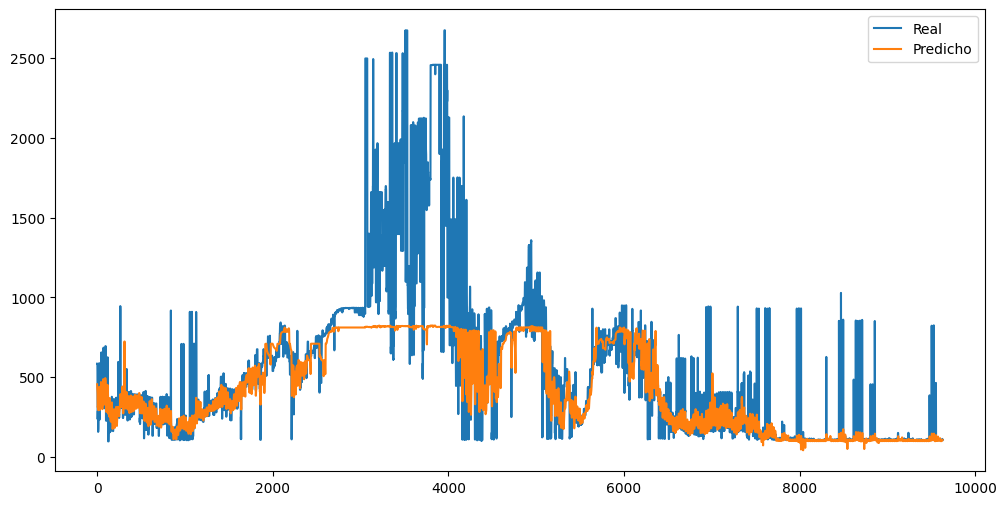

In [27]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()